## 문제 1: 당뇨병 발생 예측을 위한 데이터 탐색
- 당신은 병원의 데이터 분석가로, 여성 환자들의 건강 검진 데이터를 바탕으로 앞으로 5년 이내에 당뇨병이 발병할지를 예측하는 모델을 개발하고 있습니다.
- 이제 Pima Indian Diabetes 데이터셋(`diabetes.csv`)을 불러와서 기본적인 탐색을 해봅시다. 
- 데이터셋에는 임신 횟수, 포도당 수치, 혈압, 체질량지수(BMI) 등의 건강 정보와 당뇨병 발생 여부가 포함되어 있습니다.
- 우선 데이터를 로드하고, 샘플 수와 피처(특징) 수를 확인한 후, 타겟 변수가 무엇인지 파악하고 분포(값 0과 1의 개수)를 살펴보세요.

In [1]:
import pandas as pd
df = pd.read_csv('diabetes.csv')  # Pima Indian Diabetes dataset
print(df.shape)
print(df.columns)
print(df['Outcome'].value_counts())
df.head()  

(768, 9)
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')
Outcome
0    500
1    268
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 문제 2: 의료 데이터의 결측치 처리
- 앞서 살펴본 당뇨병 데이터에는 결측치가 있는지 파악하고, 있다면 중앙값으로 채워보세요.
- 변경 후 해당 열들의 0 값 개수가 모두 0이 되었는지 확인해보세요.

In [2]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## 문제 3: 모델 학습을 위한 데이터 분할
- 모델을 제대로 평가하려면 데이터를 훈련 세트와 테스트 세트로 나누어야 합니다.
- 이제 깨끗하게 전처리된 당뇨병 데이터를 사용하여, 입력 변수(Outcome을 제외한 모든 열)와 타겟 변수(Outcome)를 분리한 뒤, 훈련용과 테스트용 데이터셋으로 분할하세요.
- 일반적으로 전체 데이터의 70%를 훈련에, 30%를 테스트에 사용합니다.
- 분할에는 사이킷런의 train_test_split 함수를 사용하고, 무작위 분할에 따른 재현성을 위해 random_state=42를 설정하세요.

In [3]:
from sklearn.model_selection import train_test_split
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(X_train.shape, X_test.shape)

(537, 8) (231, 8)


## 문제 4: 로지스틱 회귀 모델 학습
- 이제 분류 모델을 훈련해보겠습니다. 당뇨병 발생 여부를 예측하기 위해 로지스틱 회귀 분류 모델을 선택합니다.
- 사이킷런의 LogisticRegression 클래스를 사용하여 이전 문제에서 나눈 훈련 데이터(X_train, y_train)로 모델을 학습시키세요. (다른 분류 모델 연습 해보세요!)
- 모델을 생성할 때 기본 매개변수를 사용하되, 경우에 따라 반복 횟수(max_iter)를 늘려야 할 수도 있습니다.
- 모델 학습이 완료되면, 학습된 모델 객체를 출력하여 성공적으로 만들어졌는지 확인해보세요.

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=200, random_state=42)
model.fit(X_train, y_train)
print(model)

LogisticRegression(max_iter=200, random_state=42)


## 문제 5: 분류 모델 성능 평가
- 훈련된 로지스틱 회귀 모델의 성능을 테스트 세트에서 평가해봅시다.
- 우선 테스트 세트(X_test)에 대한 예측값을 생성하고, 실제 값(y_test)과 비교하여 혼동 행렬(Confusion Matrix)을 구하세요.
- 또한 모델의 정확도(Accuracy), 정밀도(Precision), 재현율(Recall)을 계산해보세요.
-  사이킷런의 confusion_matrix 함수와 classification_report 함수를 활용하면 편리합니다.
- 의료 도메인에서는 재현율(Recall)이 특히 중요할 수 있다는 점에 유의하세요.

In [5]:
from sklearn.metrics import confusion_matrix, classification_report
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[120  31]
 [ 30  50]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.79      0.80       151
           1       0.62      0.62      0.62        80

    accuracy                           0.74       231
   macro avg       0.71      0.71      0.71       231
weighted avg       0.74      0.74      0.74       231



# ----------------------------------------------------------------

## 문제 6: 자동차 연비 예측 데이터 준비
- 당신은 자동차 제조사의 데이터 분석가로, 자동차의 제원으로부터 연비(MPG)를 예측하는 모델을 만들고 있습니다.
- 예제로 사용할 데이터는 1970-80년대 자동차의 연비를 모아둔 Auto MPG 데이터셋입니다.
- 이 데이터에는 연비(mpg), 실린더 수(cylinders), 배기량(displacement), 마력(horsepower), 차량 중량(weight), 가속성능(acceleration), 출시년도(model year), 제조국가(origin), 그리고 자동차 이름(car name)이 포함되어 있습니다.
- 모델 학습에 사용할 수 있도록 다음을 수행하세요

1. `auto-mpg.csv` 파일을 판다스로 불러옵니다 (만약 horsepower 열에 '?'로 표시된 값이 있다면, 이를 NaN으로 인식하도록 na_values='?' 옵션을 사용하세요).
2. car name 열은 연비 예측에 사용하지 않으므로 삭제(drop)합니다.
3. horsepower 열에 결측치(NaN)이 존재하면 해당 행을 제거(drop)합니다.
4. 최종 데이터프레임의 크기(행, 열 수)를 확인하세요.

In [6]:
import pandas as pd
df_mpg = pd.read_csv('auto-mpg.csv', na_values='?')
df_mpg.drop('car name', axis=1, inplace=True)
df_mpg.dropna(subset=['horsepower'], inplace=True)
print(df_mpg.shape)
df_mpg.head()

(392, 8)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,1
1,15.0,8,350.0,165.0,3693,11.5,70,1
2,18.0,8,318.0,150.0,3436,11.0,70,1
3,16.0,8,304.0,150.0,3433,12.0,70,1
4,17.0,8,302.0,140.0,3449,10.5,70,1


## 문제 7: 연비와 특성 간의 상관관계 분석
- 연비에 영향을 주는 주요 특성을 파악하기 위해, 각 특성과 타겟 값(mpg) 사이의 상관계수를 구해보겠습니다.
- 판다스의 corr() 메소드를 사용하면 손쉽게 상관계수 행렬을 얻을 수 있습니다.
- 특히 어떤 특성들이 연비와 강한 양의 또는 음의 상관관계를 가지는지 확인하고, 연비 예측에 중요할 것으로 예상되는 두 개의 특성을 골라보세요.

In [7]:
corr_matrix = df_mpg.corr()
print(corr_matrix['mpg'].sort_values(ascending=False))

mpg             1.000000
model year      0.580541
origin          0.565209
acceleration    0.423329
cylinders      -0.777618
horsepower     -0.778427
displacement   -0.805127
weight         -0.832244
Name: mpg, dtype: float64


해설 : 

양(+)의 상관관계 - 한 변수가 증가할 때 다른 변수도 함께 증가(또는 둘 다 감소)하는 경향.  
음(–)의 상관관계 - 변수가 증가할 때 다른 변수는 감소하는 경향.

## 문제 8: 데이터 분할 및 특성 인코딩
- 이제 연비 예측을 위한 모델을 준비하기 위해 데이터를 훈련 세트와 테스트 세트로 나누겠습니다.
- 연비(mpg)가 예측 대상이므로 이 열을 타겟 y로 두고, 나머지 특성들을 입력 변수 X로 사용하세요.
- 우선 데이터 분할을 8:2 비율(훈련:테스트)로 수행합니다.
- 또한 origin 열은 숫자로 국가를 나타내지만 이는 순서 의미가 없는 범주형 데이터입니다. origin을 원-핫 인코딩(one-hot encoding)하여 범주형 변수를 처리하세요.
- 인코딩 후 X_train과 X_test의 형태(shape)를 출력하여 열 수가 증가했는지 확인해보세요.

In [8]:
from sklearn.model_selection import train_test_split
X = df_mpg.drop('mpg', axis=1)
y = df_mpg['mpg']
# 원-핫 인코딩: origin 열
X = pd.get_dummies(X, columns=['origin'], prefix='origin')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(313, 9) (79, 9)


## 문제 9: 선형 회귀 모델 학습
- 이제 연비를 예측할 수 있는 선형 회귀 모델을 학습시켜보겠습니다.
- 사이킷런의 LinearRegression 모델을 사용하여, 앞서 준비한 X_train과 y_train 데이터를 가지고 모델을 학습(fit)하세요. (선형 회귀 모델말고 다른 모델을 사용해보세요!)
- 모델 학습이 완료되면, 학습된 회귀 모델의 회귀 계수(coefficient)와 절편(intercept)을 출력해보세요. 이를 통해 각 특성이 연비에 미치는 영향력을 파악할 수 있습니다.

In [9]:
from sklearn.linear_model import LinearRegression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
print("회귀 계수:", lin_model.coef_)
print("절편:", lin_model.intercept_)

회귀 계수: [-0.34210131  0.01920596 -0.0216204  -0.00642267  0.04219811  0.79716146
 -2.02715623  0.84834323  1.17881301]
절편: -17.30477379029261


## 문제 10: 회귀 모델 평가
- 학습된 선형 회귀 모델의 성능을 테스트 세트에서 평가해보겠습니다. 테스트 세트(X_test)에 대한 예측값을 구하고, 이를 실제값(y_test)과 비교하여 평균제곱오차(MSE)와 결정계수(R^2)를 계산하세요.
- MSE는 예측값과 실제값 간의 오차 제곱 평균으로, 낮을수록 좋으며, 필요에 따라 RMSE(평균제곱오차의 제곱근)로 해석하기도 합니다. R^2 점수는 모델이 타겟 변동의 몇 %를 설명하는지 나타내며, 1에 가까울수록 좋은 모델입니다.  
- 사이킷런의 mean_squared_error 함수와 r2_score 함수를 사용하세요.
- 또한 예측값과 실제값의 분포를 비교하기 위해 둘의 관계를 나타내는 산점도를 그려보세요.

MSE: 10.60, RMSE: 3.26, R^2: 0.792


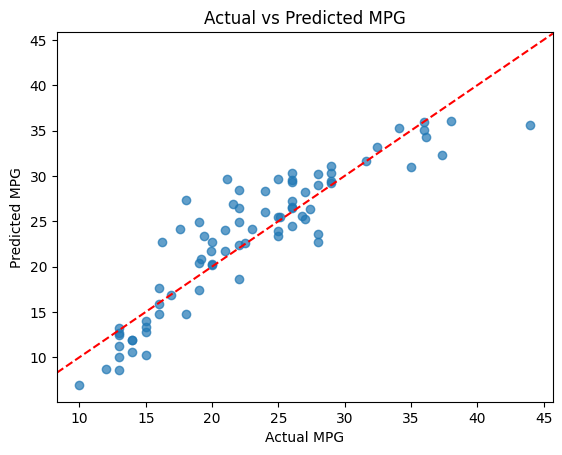

In [10]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = lin_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}, RMSE: {rmse:.2f}, R^2: {r2:.3f}")

# 실제값 vs 예측값 산점도
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title('Actual vs Predicted MPG')
plt.axline([y_test.min(), y_test.min()], [y_test.max(), y_test.max()], color='red', linestyle='--')
plt.show()

해설 : 

MSE가 10.6라면 RMSE는 약 3.26로, 평균적으로 예측이 실제 연비에서 3.26 mpg 정도 차이 난다는 뜻입니다. R^2 점수가 0.79이라면, 모델이 연비 변화의 79%를 설명한다는 의미입니다. 산점도 그래프에서는 x축에 실제 연비, y축에 예측 연비를 두어, 점들이 대각선에 얼마나 가까이 모여있는지로 모델의 성능을 시각적으로 평가할 수 있습니다. 대부분의 점들이 대각선 근처에 있다면 예측이 실제와 유사함을 보여주며, 점들이 많이 흩어져 있으면 오차가 큰 것입니다. 평가 결과를 바탕으로 모델이 충분히 정확한지, 혹은 개선이 필요한지 판단할 수 있습니다.

# ----------------------------------------------------------------

## 문제 11: 고객 군집화를 위한 데이터 불러오기
- 이번에는 군집화(Clustering) 작업을 수행해보겠습니다. 한 도매 업체의 고객 데이터를 활용하여 비슷한 소비 성향의 고객들을 군집으로 묶어보는 것이 목표입니다.
- 사용할 데이터셋은 UCI 머신러닝 저장소의 Wholesale Customers 데이터(`Wholesale customers data.csv`)로, 각 고객이 연간 얼마나 Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicatessen 항목을 구매하는지 금액으로 나타낸 것입니다.
- 우선 데이터를 불러와서 구조를 확인하고, 분석에 필요하지 않은 열(예: 채널이나 지역 정보)이 있다면 제거하세요. 
- 그런 다음, 특성별 통계 요약 (평균, 표준편차 등)을 describe() 함수로 출력해 봅시다.

In [11]:
df_wholesale = pd.read_csv('Wholesale customers data.csv')
# 필요 없는 열 제거 (채널, 지역 등)
df_wholesale.drop(['Channel', 'Region'], axis=1, inplace=True)
print(df_wholesale.shape)
df_wholesale.describe()

(440, 6)


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


## 문제 12: 특성 스케일링
- 군집화 알고리즘(예: K-평균)은 특성들의 스케일에 영향을 많이 받습니다.
- 특성들마다 구매 금액의 규모가 크게 다르기 때문에, 모든 특성을 동일한 스케일로 맞춰주는 정규화 또는 표준화가 필요합니다. 여기서는 표준화(Standardization)를 위해 사이킷런의 StandardScaler를 사용하겠습니다.
- df_wholesale 데이터의 특성들을 표준화하고, 변환된 결과를 NumPy 배열 또는 데이터프레임으로 저장하세요. 
- 스케일링 전후의 변화를 확인하기 위해 표준화된 데이터의 평균과 표준편차를 계산해 출력해 보세요 (표준화 후 각 열의 평균은 0, 표준편차는 1 수준이어야 합니다).

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_wholesale = scaler.fit_transform(df_wholesale)

import numpy as np
print("평균:", np.round(X_wholesale.mean(axis=0), 4))
print("표준편차:", np.round(X_wholesale.std(axis=0), 4))

평균: [-0.  0. -0.  0.  0. -0.]
표준편차: [1. 1. 1. 1. 1. 1.]


## 문제 13: 최적 군집 수 탐색 (엘보우 방법) -> 이론 자료 참고
- K-평균 군집화에서는 군집 수 k를 적절히 선택하는 것이 중요합니다. 
- 엘보우 방법(Elbow Method)은 다양한 k값에 대해 군집 내 거리 제곱합(Within-Cluster Sum of Squares, WCSS 또는 관성(Inertia))을 계산하고 그 변화를 관찰하여, 급격한 변화(엘보우 형태)를 보이는 지점을 최적의 k로 선택하는 기법입니다.
- 표준화된 데이터 X_wholesale에 대해 k=1부터 k=10까지 K-평균 알고리즘을 적용하여 WCSS(관성) 값을 구하세요. 각 k에 대한 WCSS 값을 리스트나 배열에 저장한 후, k를 x축으로, WCSS를 y축으로 하는 엘보우 곡선을 그려서 어느 지점에서 기울기 감소가 완만해지는지 확인해보세요.


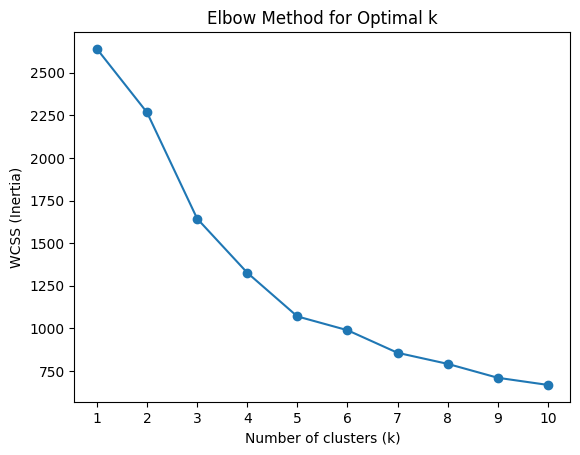

In [13]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
wcss = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_wholesale)
    wcss.append(kmeans.inertia_)
    
# Elbow plot
plt.plot(list(K_range), wcss, marker='o')
plt.xticks(list(K_range))
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.show()

해설 : 

엘보우 그래프에서 완만해지는 지점(그래프 모양이 팔꿈치처럼 꺾이는 지점)이 최적의 군집 수로 고려됩니다.

## 문제 14: K-평균 군집화 적용
- 엘보우 방법을 통해 결정한 군집 수 $k$를 사용하여 K-평균 군집화를 수행하세요.
- 사이킷런의 KMeans 클래스를 이용하여 X_wholesale 데이터에 클러스터 레이블을 할당하고, 각 클러스터의 중심점을 확인해보세요. 
- 군집화가 완료되면 각 클러스터에 속한 데이터 포인트의 개수를 출력하고, 클러스터 센터(중심)의 좌표를 확인합니다.
- 필요하다면 scaler.inverse_transform을 활용하여 클러스터 중심의 값을 원래 단위로 변환해 볼 수도 있습니다 (원본 단위로 보면 각 군집의 소비 특성 규모를 해석하기 쉬움).

In [14]:
from sklearn.cluster import KMeans
import numpy as np
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_wholesale)
print(cluster_labels)

unique, counts = np.unique(cluster_labels, return_counts=True)
print(f"클러스터별 데이터 개수: {dict(zip(unique, counts))}")
print("클러스터 중심(표준화 공간):\n", kmeans.cluster_centers_)
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
print("\n클러스터 중심(원본 단위):\n", np.round(centers_original, 1))

[0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 2 1 0 0 0 2 1 0 0 0 1 0 0 1
 0 0 1 1 0 0 2 0 2 2 2 0 2 0 0 1 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 0 1 1 0 0
 0 0 0 2 0 0 0 0 0 0 0 2 2 1 0 0 0 0 2 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 2 0 0
 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 2 0 0 0 0 1 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 2 2 1 0 0 2 0 0 0 2 0 2 0 0 0 0 2 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 2 0 0 0 1 0 0 1
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 1 1 1 1 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 2 0 0 2 0 2 0 0 2 0 0 2 0 0 0 0 0 0 2 0 0 0 0 0 1 0 0 0 0 0 2 0
 2 1 0 0 0 0 0 0 0 0 2 0 0 0 0 0 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 1 1 2 0 0]
클러스터별 데이터 개수: {np.int32(0): np.int64(350), np.int32(1): np.int64(53), np.int32(2): np.int64(37)}
클러스터 중심(표준

## 문제 15: 군집 결과 해석 및 군집 특성 파악
- 마지막으로, 군집화 결과를 해석해보겠습니다.
- 각 고객이 어느 군집에 속하는지 나타내는 레이블을 원본 데이터프레임(df_wholesale)에 추가하고, 클러스터별로 평균 소비 금액을 계산하여 군집의 특징을 파악하세요.
- df_wholesale에 'Cluster' 열을 추가하여 클러스터 번호를 기록한 후, 그룹별 평균을 확인하면 각 군집의 소비 패턴 차이를 명확히 볼 수 있습니다.
- 가능하다면 이 정보를 바탕으로 각 군집에 어울리는 이름이나 특성을 설명해보세요 (예: '대량 구매 고객', '균형 구매 고객' 등).

In [15]:
df_wholesale['Cluster'] = cluster_labels
cluster_profile = df_wholesale.groupby('Cluster').mean().round(1)
print(cluster_profile)

           Fresh     Milk  Grocery  Frozen  Detergents_Paper  Delicassen
Cluster                                                                 
0         8935.5   4228.5   5848.0  2167.2            1913.6      1102.1
1        34540.1   5860.4   6122.6  9841.7             981.5      3664.2
2         8704.9  20534.4  30466.2  1932.6           14758.8      2459.4


해설 : 

클러스터 1의 고객들은 Fresh와 Frozen 항목 소비가 평균보다 훨씬 높고 Detergents_Paper는 낮다면, 해당 군집을 '신선식품 위주 고객'으로 묘사할 수 있습니다.
반면 클러스터 0은 전반적으로 모든 항목을 고르게 중간 정도 구매한다면 '균형적 소비 고객군'으로 볼 수 있습니다. 클러스터 2가 Detergents_Paper와 Grocery 항목 소비가 두드러지게 높다면 '소매점/마트형 고객'일 가능성이 있습니다.  
이처럼 군집별 프로파일을 해석하여 붙인 레이블은 비즈니스 의사결정에 활용될 수 있습니다. 예를 들어 대량으로 Fresh 품목을 구매하는 군집에는 신선식품 할인 프로모션을 제공하고, Detergents_Paper를 많이 구매하는 군집에는 세제 관련 묶음 상품을 마케팅할 수 있을 것입니다. 군집화 분석을 통해 데이터 내 잠재된 그룹 특성을 발견하고, 도메인 지식과 결합하여 의미를 부여하는 것이 중요합니다.